In [54]:
# [setup]
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

ACCOUNTING_DATE = pd.Timestamp('2026-12-15')
PLOT_START = pd.Timestamp('2025-10-01')
PLOT_END = pd.Timestamp('2027-01-01')

# Benchmark only covers the forecast window
BENCHMARK_START = pd.Timestamp('2026-03-01')

# Color / style scheme for forecast variants + benchmark
# Solid = 02-27 (pre-shutdown baseline); dashed = 04-01
# Blue family = unmodified (april); orange = no-iran; green = fake-iran; black = benchmark
DATASET_STYLES = {
    'april/02-27':     {'color': '#1565C0', 'linestyle': '-',  'linewidth': 1.4, 'label': 'unmodified / 2026-02-27'},
    'april/04-01':     {'color': '#42A5F5', 'linestyle': '--', 'linewidth': 1.4, 'label': 'unmodified / 2026-04-01'},
#   'april/04-05':     {'color': '#90CAF9', 'linestyle': ':',  'linewidth': 1.8, 'label': 'unmodified / 2026-04-05'},
    'no-iran/02-27':   {'color': '#E65100', 'linestyle': '-',  'linewidth': 1.4, 'label': 'no-iran / 2026-02-27'},
    'no-iran/04-01':   {'color': '#FF7043', 'linestyle': '--', 'linewidth': 1.4, 'label': 'no-iran / 2026-04-01'},
#   'no-iran/04-05':   {'color': '#FFAB40', 'linestyle': ':',  'linewidth': 1.8, 'label': 'no-iran / 2026-04-05'},
    'fake-iran/02-27': {'color': '#2E7D32', 'linestyle': '-',  'linewidth': 1.4, 'label': 'fake-iran / 2026-02-27'},
    'fake-iran/04-01': {'color': '#43A047', 'linestyle': '--', 'linewidth': 1.4, 'label': 'fake-iran / 2026-04-01'},
#   'fake-iran/04-05': {'color': '#66BB6A', 'linestyle': ':',  'linewidth': 1.8, 'label': 'fake-iran / 2026-04-05'},
    'benchmark':       {'color': '#000000', 'linestyle': ':',  'linewidth': 2.5, 'label': 'benchmark (Brad MA28)'},
}

print('Setup complete.')


Setup complete.


In [55]:
# [load-data]
BASE_DIR = 'data-official/comparisons'

FORECAST_FILES = {
    'april/02-27':     f'{BASE_DIR}/april/2026-02-27/mozaic_daily_forecast.2026-02-27.gm+ld-D.parquet',
    'april/04-01':     f'{BASE_DIR}/april/2026-04-01/mozaic_daily_forecast.2026-04-01.gm+ld-D.parquet',
#   'april/04-05':     f'{BASE_DIR}/april/2026-04-05/mozaic_daily_forecast.2026-04-05.gm+ld-D.parquet',
    'no-iran/02-27':   f'{BASE_DIR}/no-iran/2026-02-27/mozaic_daily_forecast.2026-02-27.gm+ld-D.parquet',
    'no-iran/04-01':   f'{BASE_DIR}/no-iran/2026-04-01/mozaic_daily_forecast.2026-04-01.gm+ld-D.parquet',
#   'no-iran/04-05':   f'{BASE_DIR}/no-iran/2026-04-05/mozaic_daily_forecast.2026-04-05.gm+ld-D.parquet',
    'fake-iran/02-27': f'{BASE_DIR}/fake-iran/2026-02-27/mozaic_daily_forecast.2026-02-27.gm+ld-D.parquet',
    'fake-iran/04-01': f'{BASE_DIR}/fake-iran/2026-04-01/mozaic_daily_forecast.2026-04-01.gm+ld-D.parquet',
#   'fake-iran/04-05': f'{BASE_DIR}/fake-iran/2026-04-05/mozaic_daily_forecast.2026-04-05.gm+ld-D.parquet',
}

BENCHMARK_FILE = 'data/benchmarks.csv'


def extract_world_dau(path, data_source, segment, app_name=None):
    """Load world-level DAU from a forecast parquet file.

    Filters to country='ALL' and the given segment / app_name aggregation row.
    Returns a DataFrame with columns: target_date, dau, data_type.
    """
    df = pd.read_parquet(path)
    mask = (
        (df['country'] == 'ALL')
        & (df['data_source'] == data_source)
        & (df['segment'] == segment)
    )
    if app_name is not None:
        mask = mask & (df['app_name'] == app_name)
    result = df.loc[mask, ['target_date', 'dau', 'data_type']].copy()
    result['target_date'] = pd.to_datetime(result['target_date'])
    result = result.sort_values('target_date').reset_index(drop=True)
    assert len(result) > 0, f'No rows matched: {path} / {data_source}'
    return result


# Load all forecast files for desktop and mobile
desktop_data = {}
mobile_data = {}

for key, path in FORECAST_FILES.items():
    desktop_data[key] = extract_world_dau(path, 'legacy_desktop', '{"os": "ALL"}')
    mobile_data[key]  = extract_world_dau(path, 'glean_mobile', '{}', app_name='ALL MOBILE')
    date_range = f"{desktop_data[key]['target_date'].min().date()} to {desktop_data[key]['target_date'].max().date()}"
    print(f'{key:22s}: {len(desktop_data[key])} desktop rows, {len(mobile_data[key])} mobile rows  [{date_range}]')

# Load benchmark — already 28-day MA values, no raw data
bench_raw = pd.read_csv(BENCHMARK_FILE)

benchmark_desktop = pd.DataFrame({
    'target_date': pd.to_datetime(bench_raw['submission_date']),
    'dau_ma28':    bench_raw['raw_28_ma - Brad'],
}).sort_values('target_date').reset_index(drop=True)

benchmark_mobile = pd.DataFrame({
    'target_date': pd.to_datetime(bench_raw['submission_date.1']),
    'dau_ma28':    bench_raw['raw_28_ma - Brad.1'],
}).sort_values('target_date').reset_index(drop=True)

print()
print(f'Benchmark desktop: {len(benchmark_desktop)} rows, '
      f'{benchmark_desktop["target_date"].min().date()} to {benchmark_desktop["target_date"].max().date()}')
print(f'Benchmark mobile:  {len(benchmark_mobile)} rows, '
      f'{benchmark_mobile["target_date"].min().date()} to {benchmark_mobile["target_date"].max().date()}')


april/02-27           : 2922 desktop rows, 2557 mobile rows  [2020-01-01 to 2027-12-31]
april/04-01           : 2922 desktop rows, 2557 mobile rows  [2020-01-01 to 2027-12-31]
no-iran/02-27         : 2922 desktop rows, 2557 mobile rows  [2020-01-01 to 2027-12-31]
no-iran/04-01         : 2922 desktop rows, 2557 mobile rows  [2020-01-01 to 2027-12-31]
fake-iran/02-27       : 2922 desktop rows, 2557 mobile rows  [2020-01-01 to 2027-12-31]
fake-iran/04-01       : 2922 desktop rows, 2557 mobile rows  [2020-01-01 to 2027-12-31]

Benchmark desktop: 306 rows, 2026-03-01 to 2026-12-31
Benchmark mobile:  306 rows, 2026-03-01 to 2026-12-31


In [56]:
# [helpers]
ALL_FORECAST_KEYS = list(FORECAST_FILES.keys())


def add_ma28(df, value_col='dau'):
    """Return a copy of df with a 'dau_ma28' column (28-day trailing mean)."""
    df = df.copy().sort_values('target_date')
    df['dau_ma28'] = df[value_col].rolling(28, min_periods=28).mean()
    return df


def trim(df, start=PLOT_START, end=PLOT_END, date_col='target_date'):
    """Filter df to [start, end] on the given date column."""
    return df[(df[date_col] >= start) & (df[date_col] <= end)].copy()


def millions_formatter(x, pos):
    """Y-axis label formatter: 50000000 -> '50.0M'."""
    return f'{x / 1e6:.1f}M'


def mark_accounting_date(ax):
    """Add a vertical dashed line at the Dec 15 accounting date."""
    ax.axvline(ACCOUNTING_DATE, color='black', linestyle='--', alpha=0.35, linewidth=1)
    ymin, ymax = ax.get_ylim()
    ax.text(ACCOUNTING_DATE, ymax, '  Dec 15', va='top', ha='left', fontsize=8, alpha=0.55)


def apply_date_axis(ax):
    """Apply monthly tick marks and angled labels to a time-series x-axis."""
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')


print('Helpers defined.')
print(f'Forecast keys: {ALL_FORECAST_KEYS}')

Helpers defined.
Forecast keys: ['april/02-27', 'april/04-01', 'no-iran/02-27', 'no-iran/04-01', 'fake-iran/02-27', 'fake-iran/04-01']


In [57]:
# [plot-lines]
def plot_lines(keys, platform='desktop', title=None, start=PLOT_START, end=PLOT_END,
               show_forecast_boundary=False):
    """Plot selected datasets for a given platform.

    Top panel: raw DAU (forecast data only — benchmark has no raw values).
    Bottom panel: 28-day MA (forecast data + benchmark if 'benchmark' in keys).

    Parameters
    ----------
    keys : list of str
        Dataset keys to plot. Forecast keys:
            'april/02-27', 'april/04-01', 'april/04-05',
            'no-iran/02-27', 'no-iran/04-01', 'no-iran/04-05',
            'fake-iran/02-27', 'fake-iran/04-01', 'fake-iran/04-05'
        Add 'benchmark' to overlay Brad's MA28 in the lower panel.
    platform : str
        'desktop' for legacy_desktop DAU, or 'mobile' for glean_mobile DAU.
    title : str, optional
        Override the default plot title.
    start, end : pd.Timestamp
        Date window to display.
    show_forecast_boundary : bool
        If True, draw a vertical line where each dataset switches from
        training to forecast data.
    """
    platform_data      = desktop_data      if platform == 'desktop' else mobile_data
    platform_benchmark = benchmark_desktop if platform == 'desktop' else benchmark_mobile
    default_title = (
        'Legacy Desktop DAU — World Level'
        if platform == 'desktop'
        else 'Glean Mobile DAU — World Level'
    )
    plot_title = title or default_title

    forecast_keys     = [k for k in keys if k != 'benchmark']
    include_benchmark = 'benchmark' in keys

    # Pre-compute forecast boundary dates per key
    boundary_dates = {}
    if show_forecast_boundary:
        for key in forecast_keys:
            df = platform_data[key]
            forecast_rows = df.loc[df['data_type'] == 'forecast', 'target_date']
            if len(forecast_rows) > 0:
                boundary_dates[key] = forecast_rows.min()

    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

    # ── Top panel: raw DAU (forecast only) ──────────────────────────────────
    ax = axes[0]
    for key in forecast_keys:
        style   = DATASET_STYLES[key]
        df_plot = trim(platform_data[key], start, end)
        ax.plot(df_plot['target_date'], df_plot['dau'],
                color=style['color'], linestyle=style['linestyle'],
                linewidth=style['linewidth'] * 0.6, alpha=0.65,
                label=style['label'])
    ax.set_title(f'{plot_title} — Raw DAU')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
    ax.legend(loc='lower left', fontsize=9)
    mark_accounting_date(ax)

    # ── Bottom panel: MA28 (forecast + optional benchmark) ──────────────────
    ax = axes[1]
    for key in forecast_keys:
        style   = DATASET_STYLES[key]
        df_ma   = add_ma28(platform_data[key])
        df_plot = trim(df_ma, start, end)
        ax.plot(df_plot['target_date'], df_plot['dau_ma28'],
                color=style['color'], linestyle=style['linestyle'],
                linewidth=style['linewidth'], alpha=0.85,
                label=style['label'])
    if include_benchmark:
        bstyle     = DATASET_STYLES['benchmark']
        bench_plot = trim(platform_benchmark, start, end)
        ax.plot(bench_plot['target_date'], bench_plot['dau_ma28'],
                color=bstyle['color'], linestyle=bstyle['linestyle'],
                linewidth=bstyle['linewidth'], alpha=0.9,
                label=bstyle['label'])
    ax.set_title(f'{plot_title} — 28-Day Moving Average')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
    ax.legend(loc='lower left', fontsize=9)
    mark_accounting_date(ax)
    apply_date_axis(ax)

    # ── Forecast boundary lines (both panels) ───────────────────────────────
    if show_forecast_boundary:
        drawn_dates = set()
        for key in forecast_keys:
            if key not in boundary_dates:
                continue
            bdate = boundary_dates[key]
            if bdate < start or bdate > end:
                continue
            style = DATASET_STYLES[key]
            already_drawn = bdate in drawn_dates
            for panel_ax in axes:
                panel_ax.axvline(bdate, color=style['color'], linestyle=':',
                                 linewidth=1.2, alpha=0.6)
                if not already_drawn:
                    ymin, ymax = panel_ax.get_ylim()
                    panel_ax.text(bdate, ymax, f'  {bdate.strftime("%m-%d")}',
                                  va='top', ha='left', fontsize=8, alpha=0.55,
                                  color=style['color'])
            drawn_dates.add(bdate)

    plt.tight_layout()
    plt.show()


print('plot_lines() defined.')
print()
print('Example usage:')
print("  plot_lines(['april/02-27', 'fake-iran/04-05', 'benchmark'], platform='desktop')")
print("  plot_lines(['no-iran/02-27', 'no-iran/04-01'], show_forecast_boundary=True)")


plot_lines() defined.

Example usage:
  plot_lines(['april/02-27', 'fake-iran/04-05', 'benchmark'], platform='desktop')
  plot_lines(['no-iran/02-27', 'no-iran/04-01'], show_forecast_boundary=True)


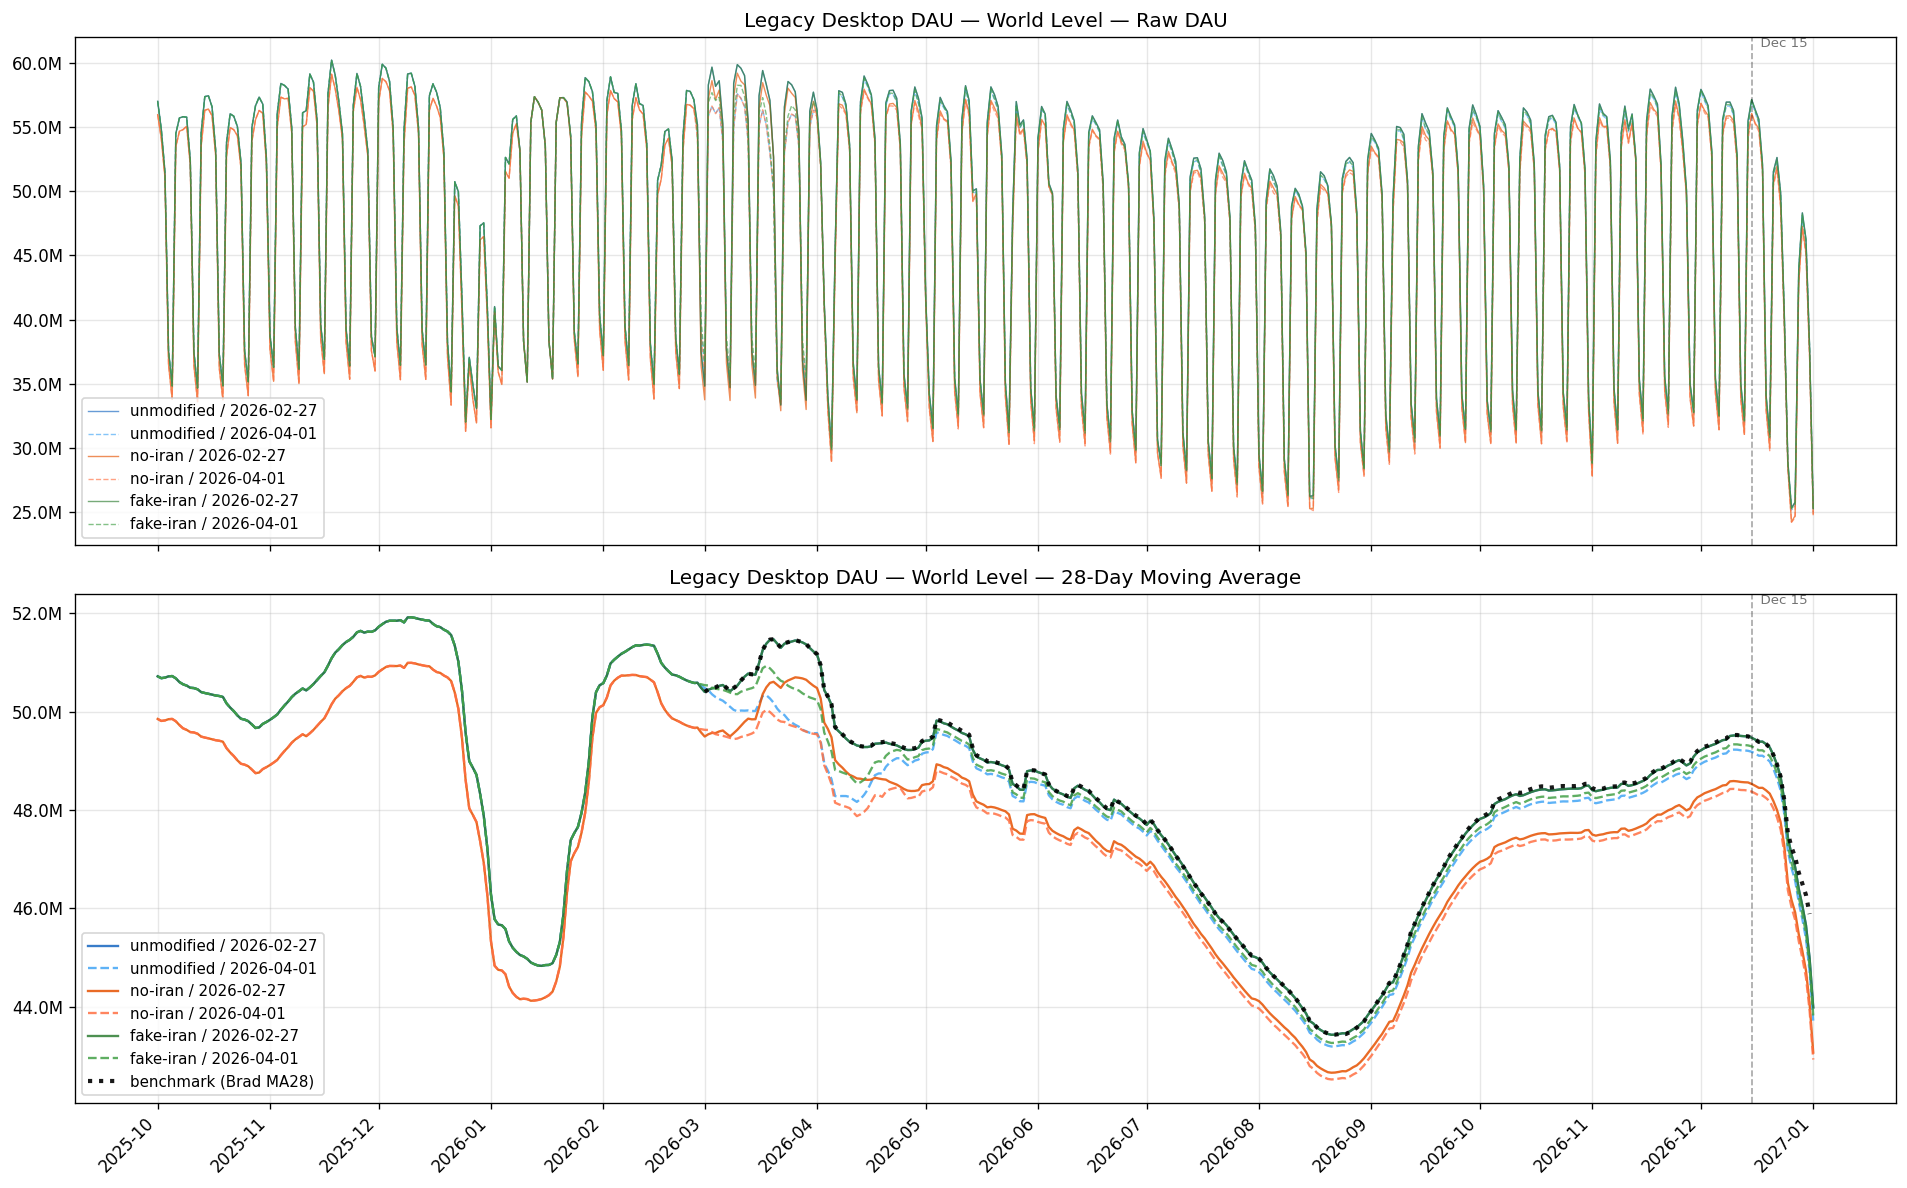

In [58]:
# [desktop-topline]
# All 9 forecast variants + benchmark MA28 overlay
plot_lines(ALL_FORECAST_KEYS + ['benchmark'], platform='desktop')

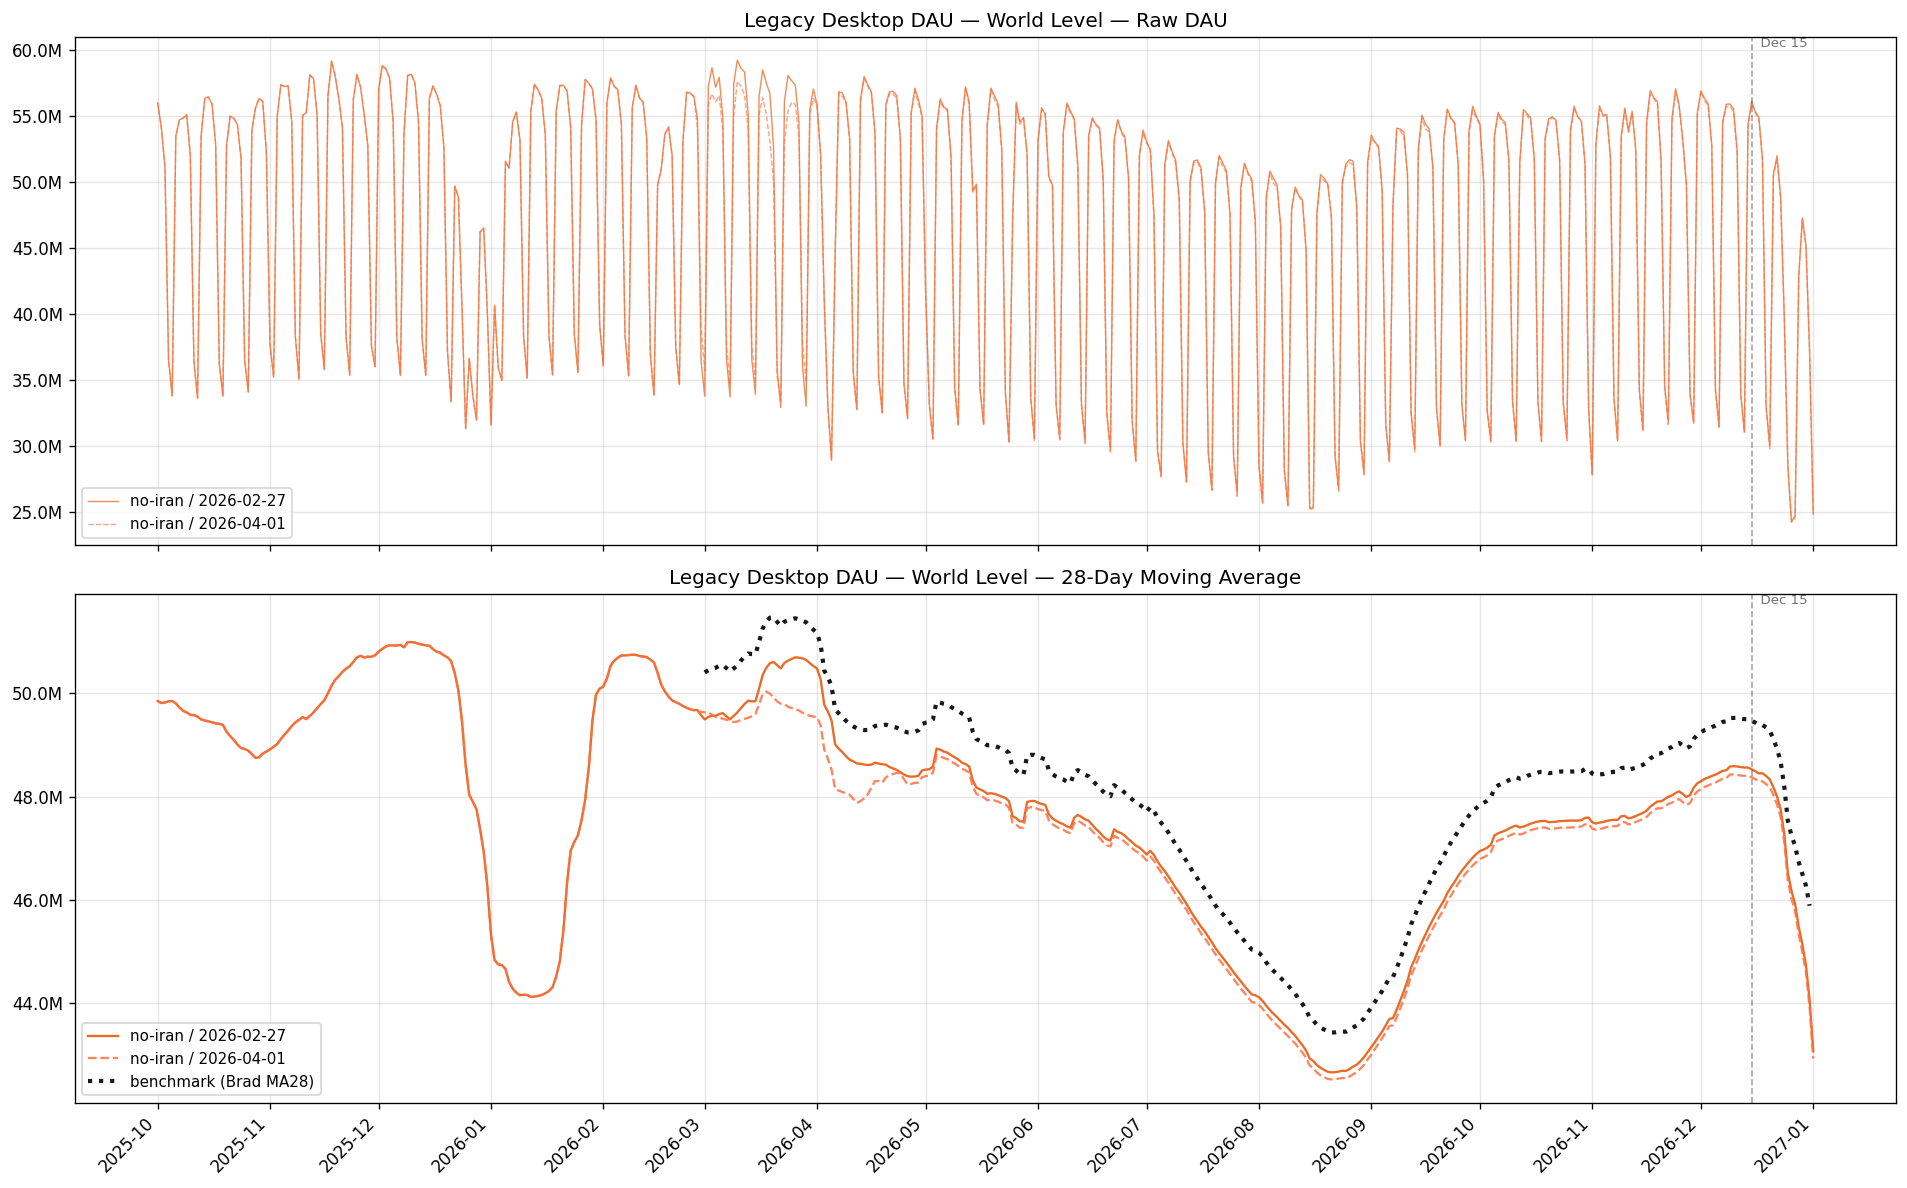

In [59]:
# [desktop-no-iran]
plot_lines(['no-iran/02-27', 'no-iran/04-01', 'benchmark'], platform='desktop')


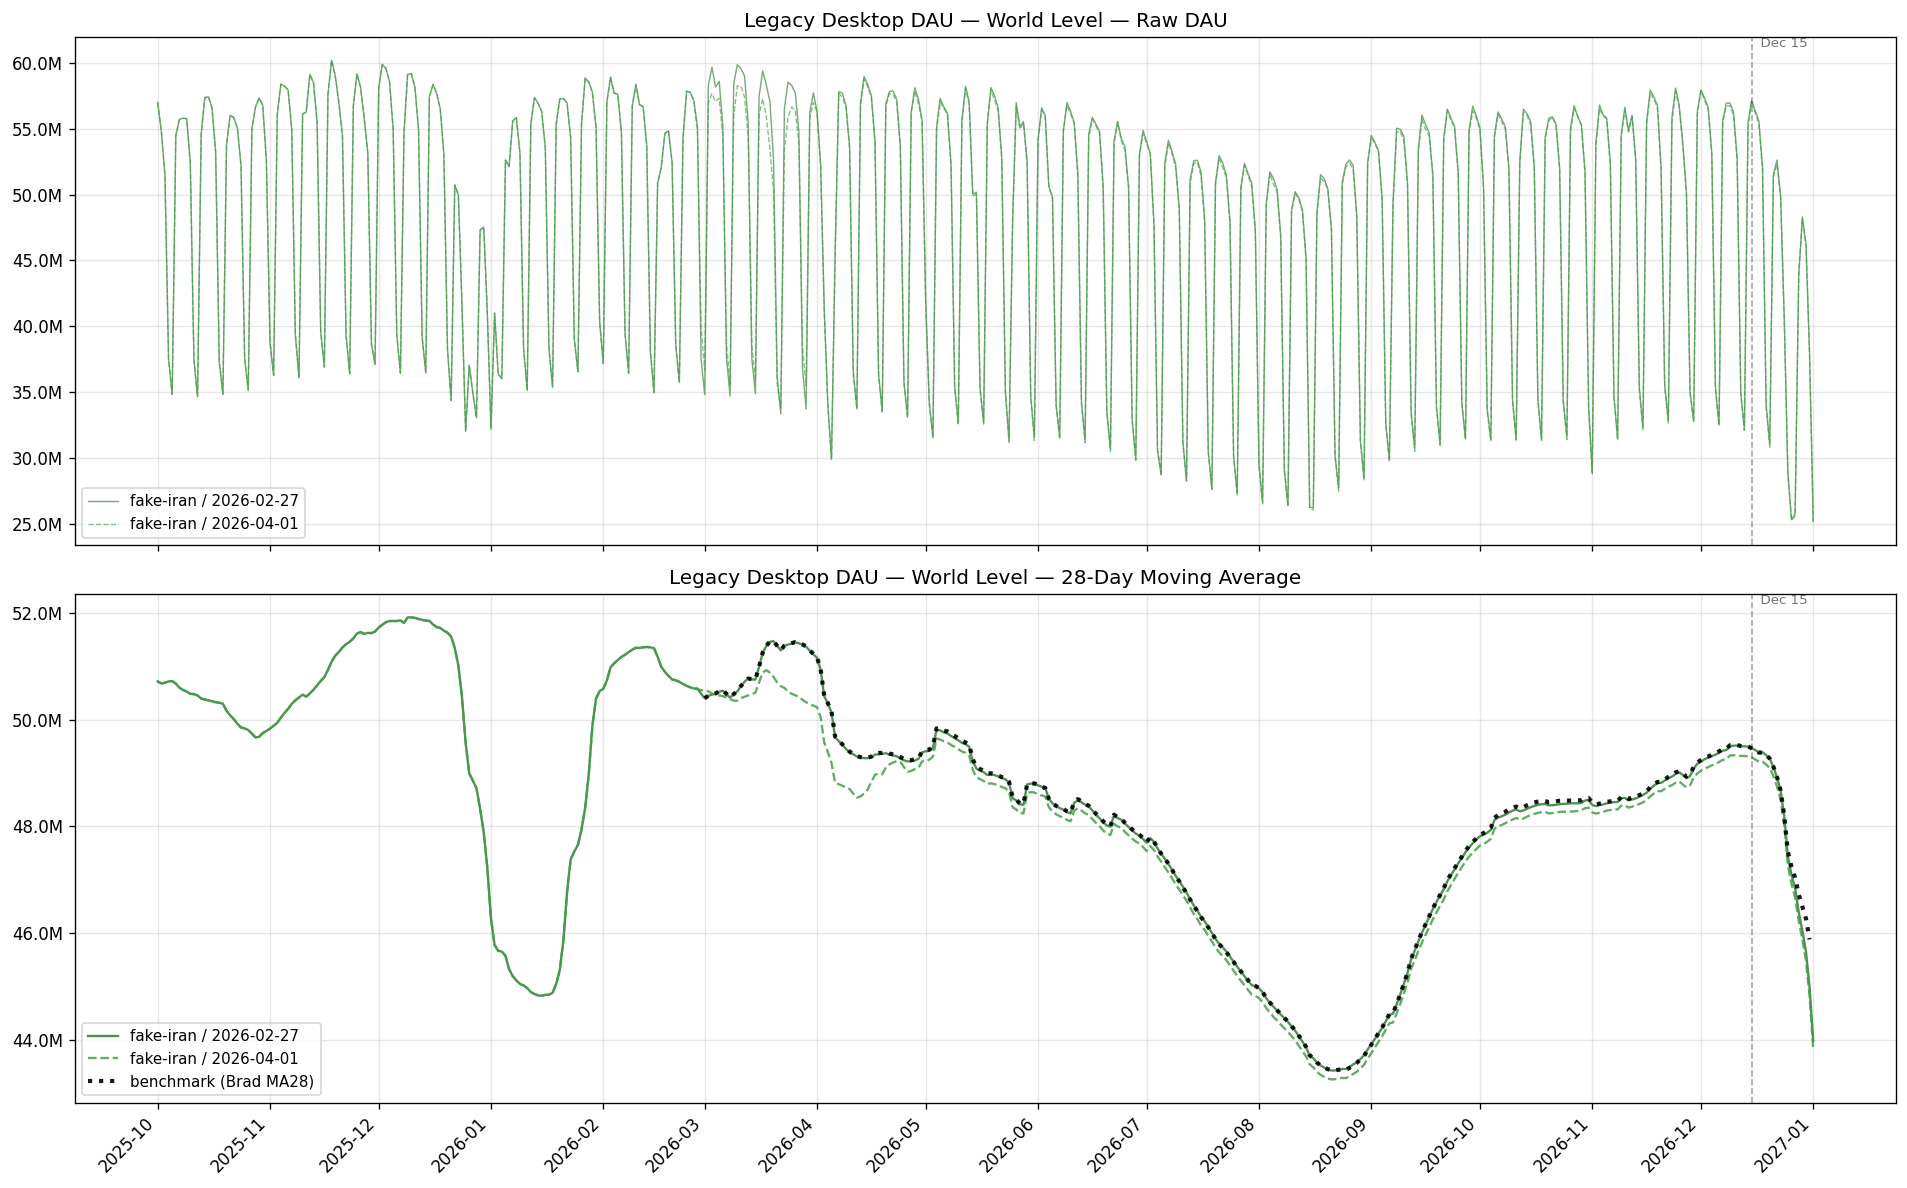

In [60]:
# [desktop-fake-iran]
plot_lines(['fake-iran/02-27', 'fake-iran/04-01', 'benchmark'], platform='desktop')


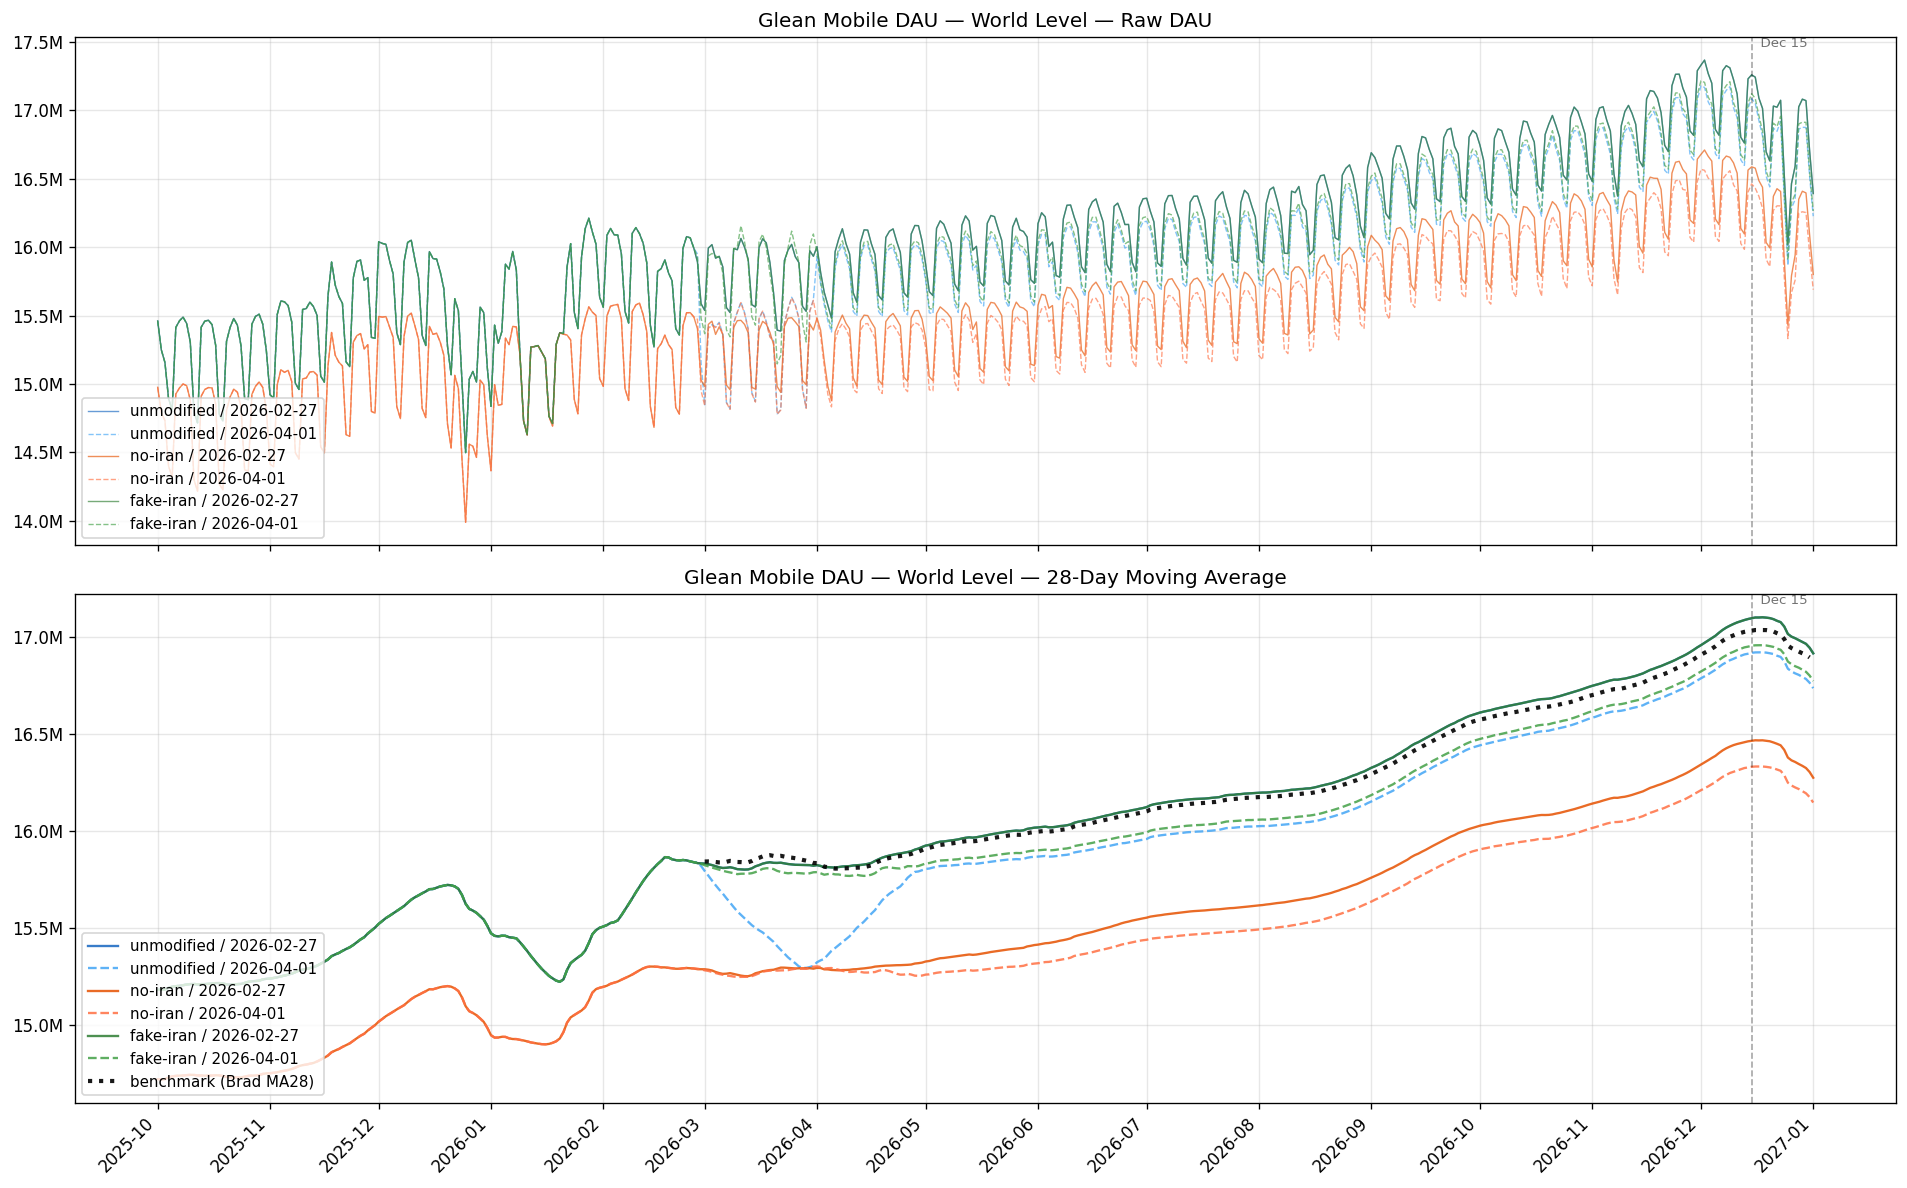

In [61]:
# [mobile-topline]
plot_lines(ALL_FORECAST_KEYS + ['benchmark'], platform='mobile')

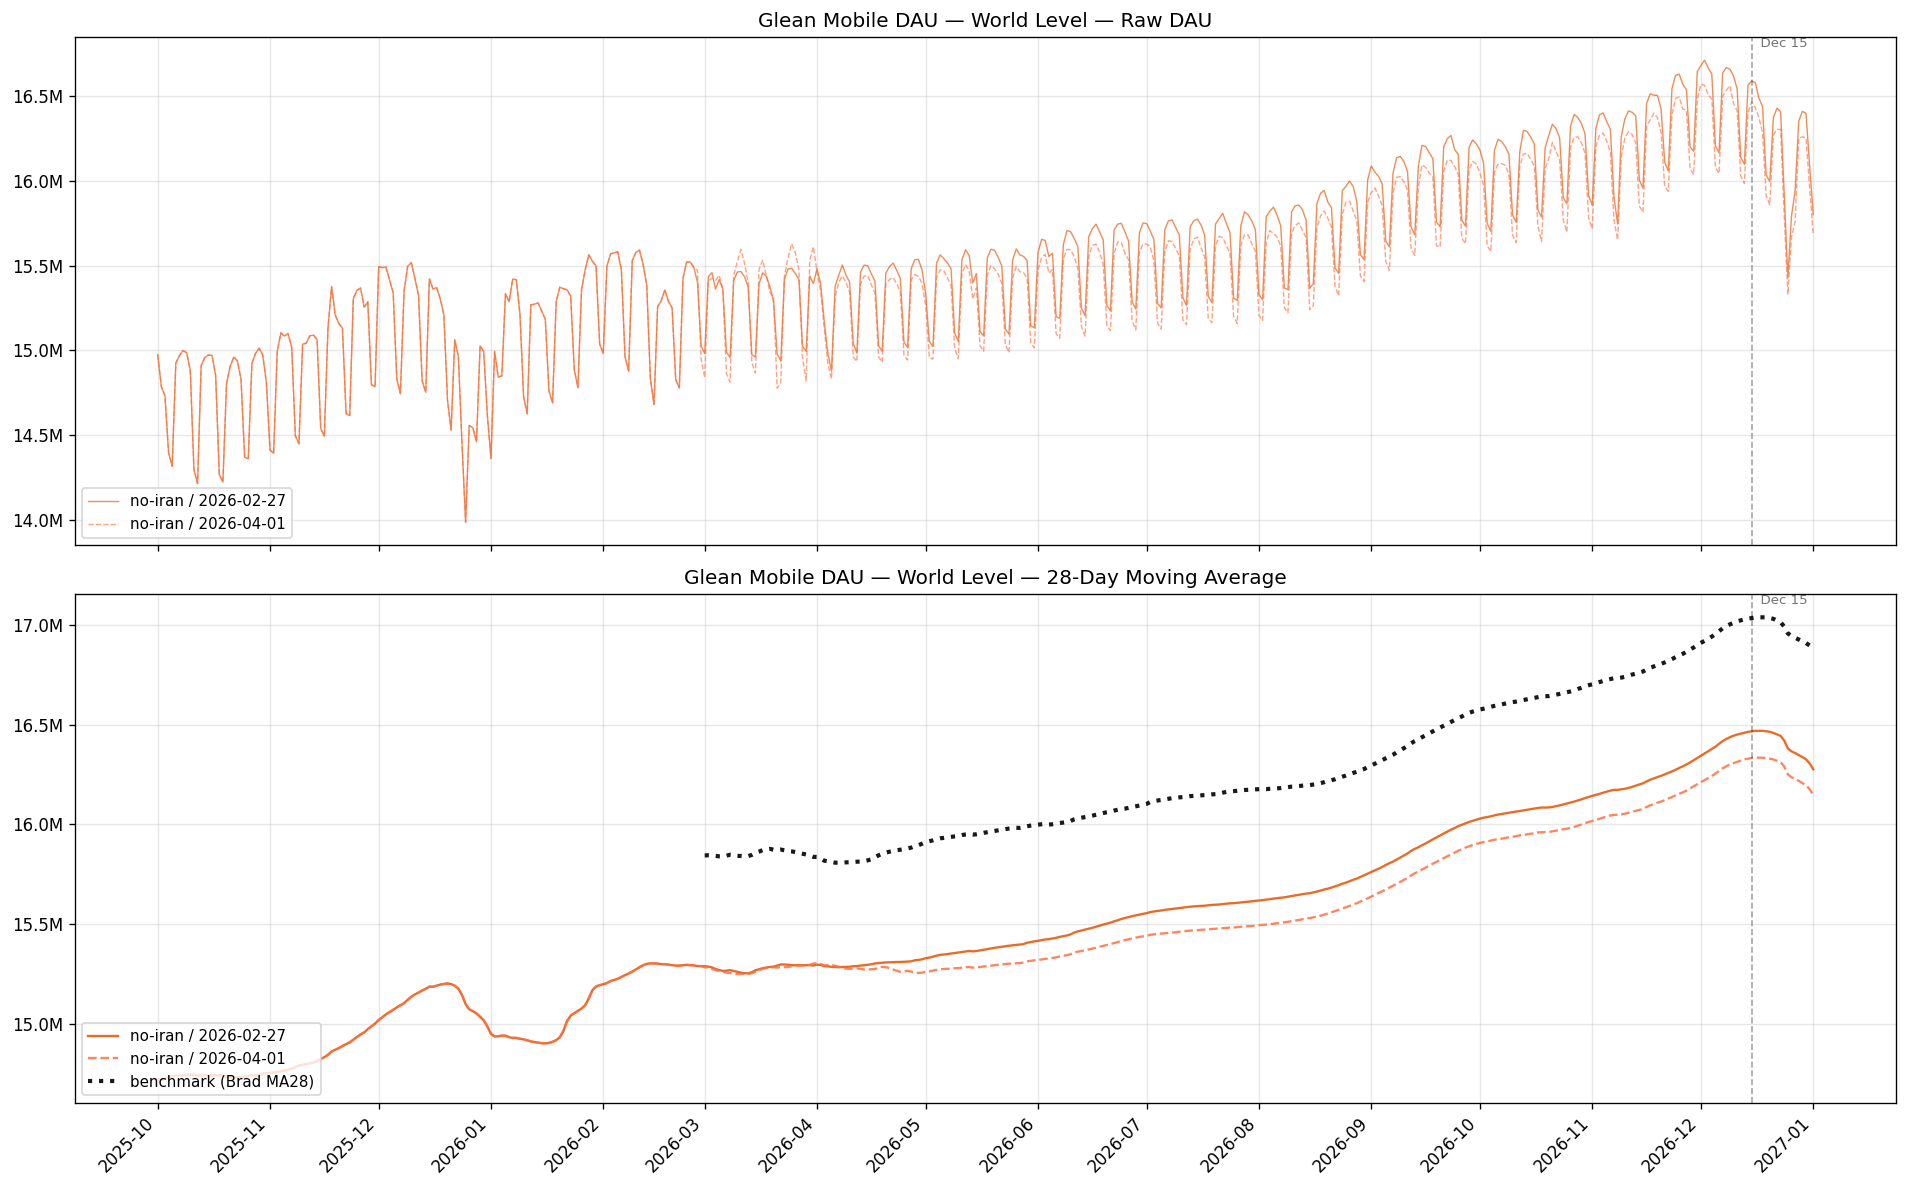

In [62]:
# [mobile-no-iran]
plot_lines(['no-iran/02-27', 'no-iran/04-01', 'benchmark'], platform='mobile')


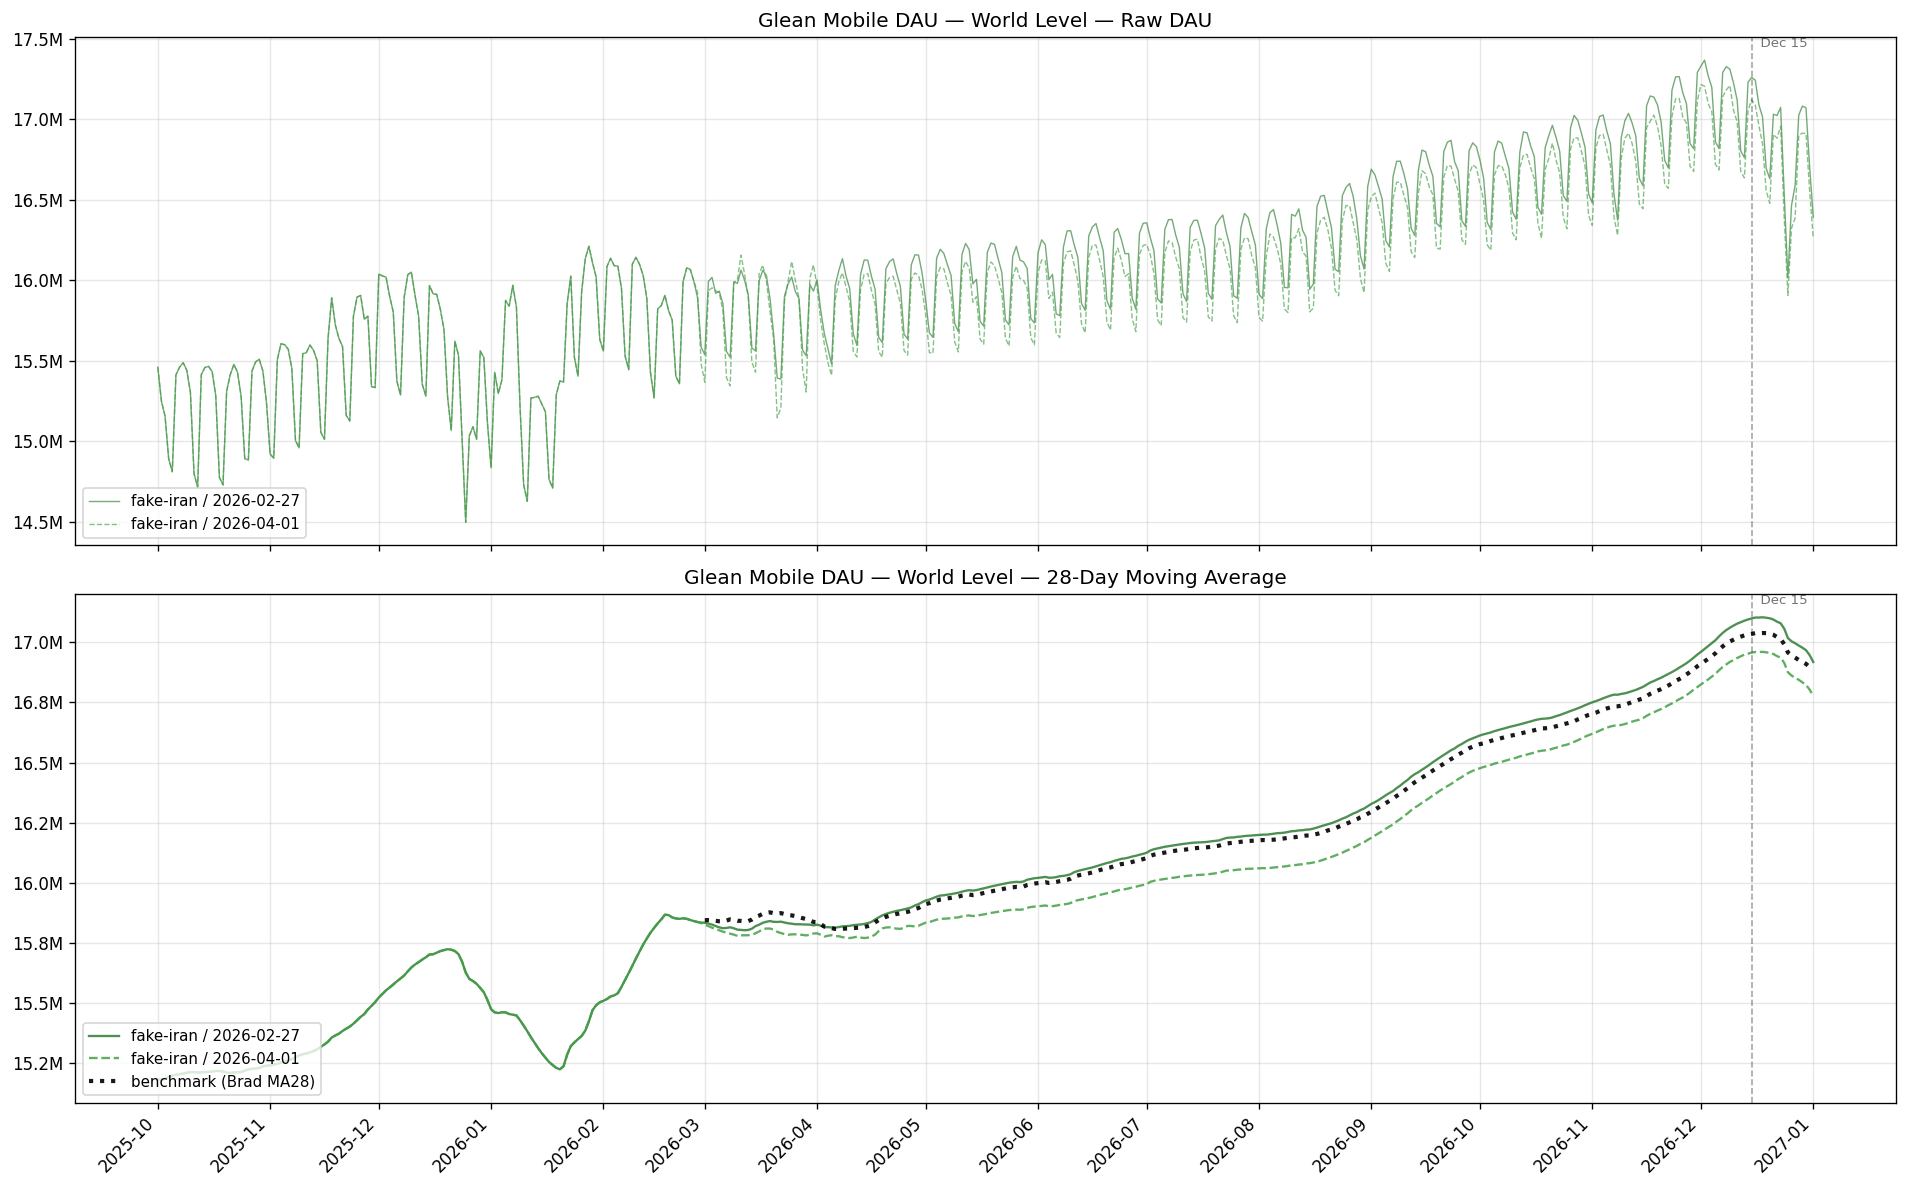

In [63]:
# [mobile-fake-iran]
plot_lines(['fake-iran/02-27', 'fake-iran/04-01', 'benchmark'], platform='mobile')


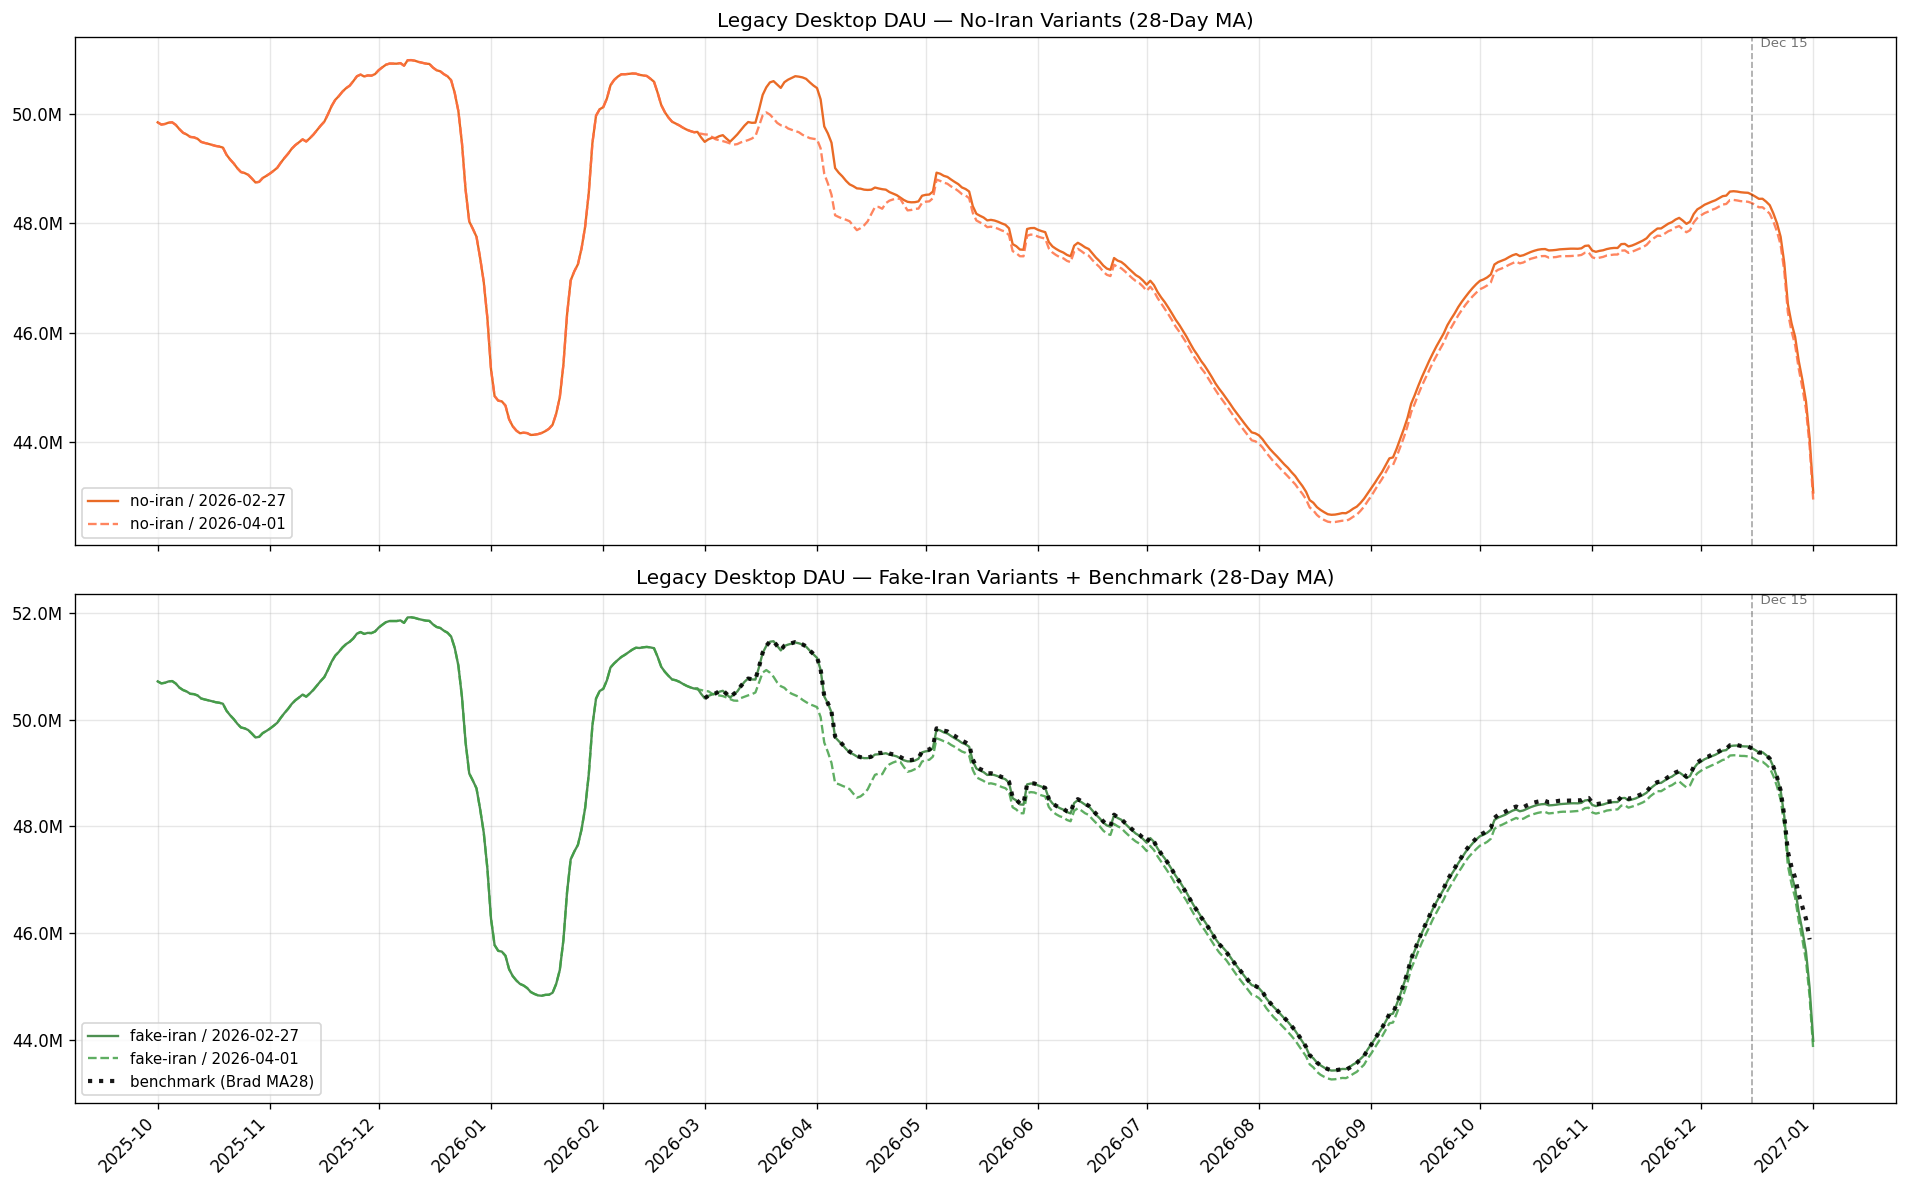

In [64]:
# [plot-no-iran-vs-fake-iran]
def plot_no_iran_vs_fake_iran(platform='desktop', start=PLOT_START, end=PLOT_END):
    """Two-panel MA28 plot: no-iran variants (top) and fake-iran variants + benchmark (bottom).

    Parameters
    ----------
    platform : str
        'desktop' or 'mobile'
    start, end : pd.Timestamp
        Date window to display.
    """
    platform_data      = desktop_data      if platform == 'desktop' else mobile_data
    platform_benchmark = benchmark_desktop if platform == 'desktop' else benchmark_mobile
    platform_label     = 'Legacy Desktop DAU' if platform == 'desktop' else 'Glean Mobile DAU'

    no_iran_keys   = ['no-iran/02-27',   'no-iran/04-01']
    fake_iran_keys = ['fake-iran/02-27', 'fake-iran/04-01']

    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

    # ── Top panel: no-iran MA28 ──────────────────────────────────────────────
    ax = axes[0]
    for key in no_iran_keys:
        style   = DATASET_STYLES[key]
        df_ma   = add_ma28(platform_data[key])
        df_plot = trim(df_ma, start, end)
        ax.plot(df_plot['target_date'], df_plot['dau_ma28'],
                color=style['color'], linestyle=style['linestyle'],
                linewidth=style['linewidth'], alpha=0.85,
                label=style['label'])
    ax.set_title(f'{platform_label} — No-Iran Variants (28-Day MA)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
    ax.legend(loc='lower left', fontsize=9)
    mark_accounting_date(ax)

    # ── Bottom panel: fake-iran MA28 + benchmark ─────────────────────────────
    ax = axes[1]
    for key in fake_iran_keys:
        style   = DATASET_STYLES[key]
        df_ma   = add_ma28(platform_data[key])
        df_plot = trim(df_ma, start, end)
        ax.plot(df_plot['target_date'], df_plot['dau_ma28'],
                color=style['color'], linestyle=style['linestyle'],
                linewidth=style['linewidth'], alpha=0.85,
                label=style['label'])
    bstyle     = DATASET_STYLES['benchmark']
    bench_plot = trim(platform_benchmark, start, end)
    ax.plot(bench_plot['target_date'], bench_plot['dau_ma28'],
            color=bstyle['color'], linestyle=bstyle['linestyle'],
            linewidth=bstyle['linewidth'], alpha=0.9,
            label=bstyle['label'])
    ax.set_title(f'{platform_label} — Fake-Iran Variants + Benchmark (28-Day MA)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
    ax.legend(loc='lower left', fontsize=9)
    mark_accounting_date(ax)
    apply_date_axis(ax)

    plt.tight_layout()
    plt.show()


plot_no_iran_vs_fake_iran(platform='desktop')


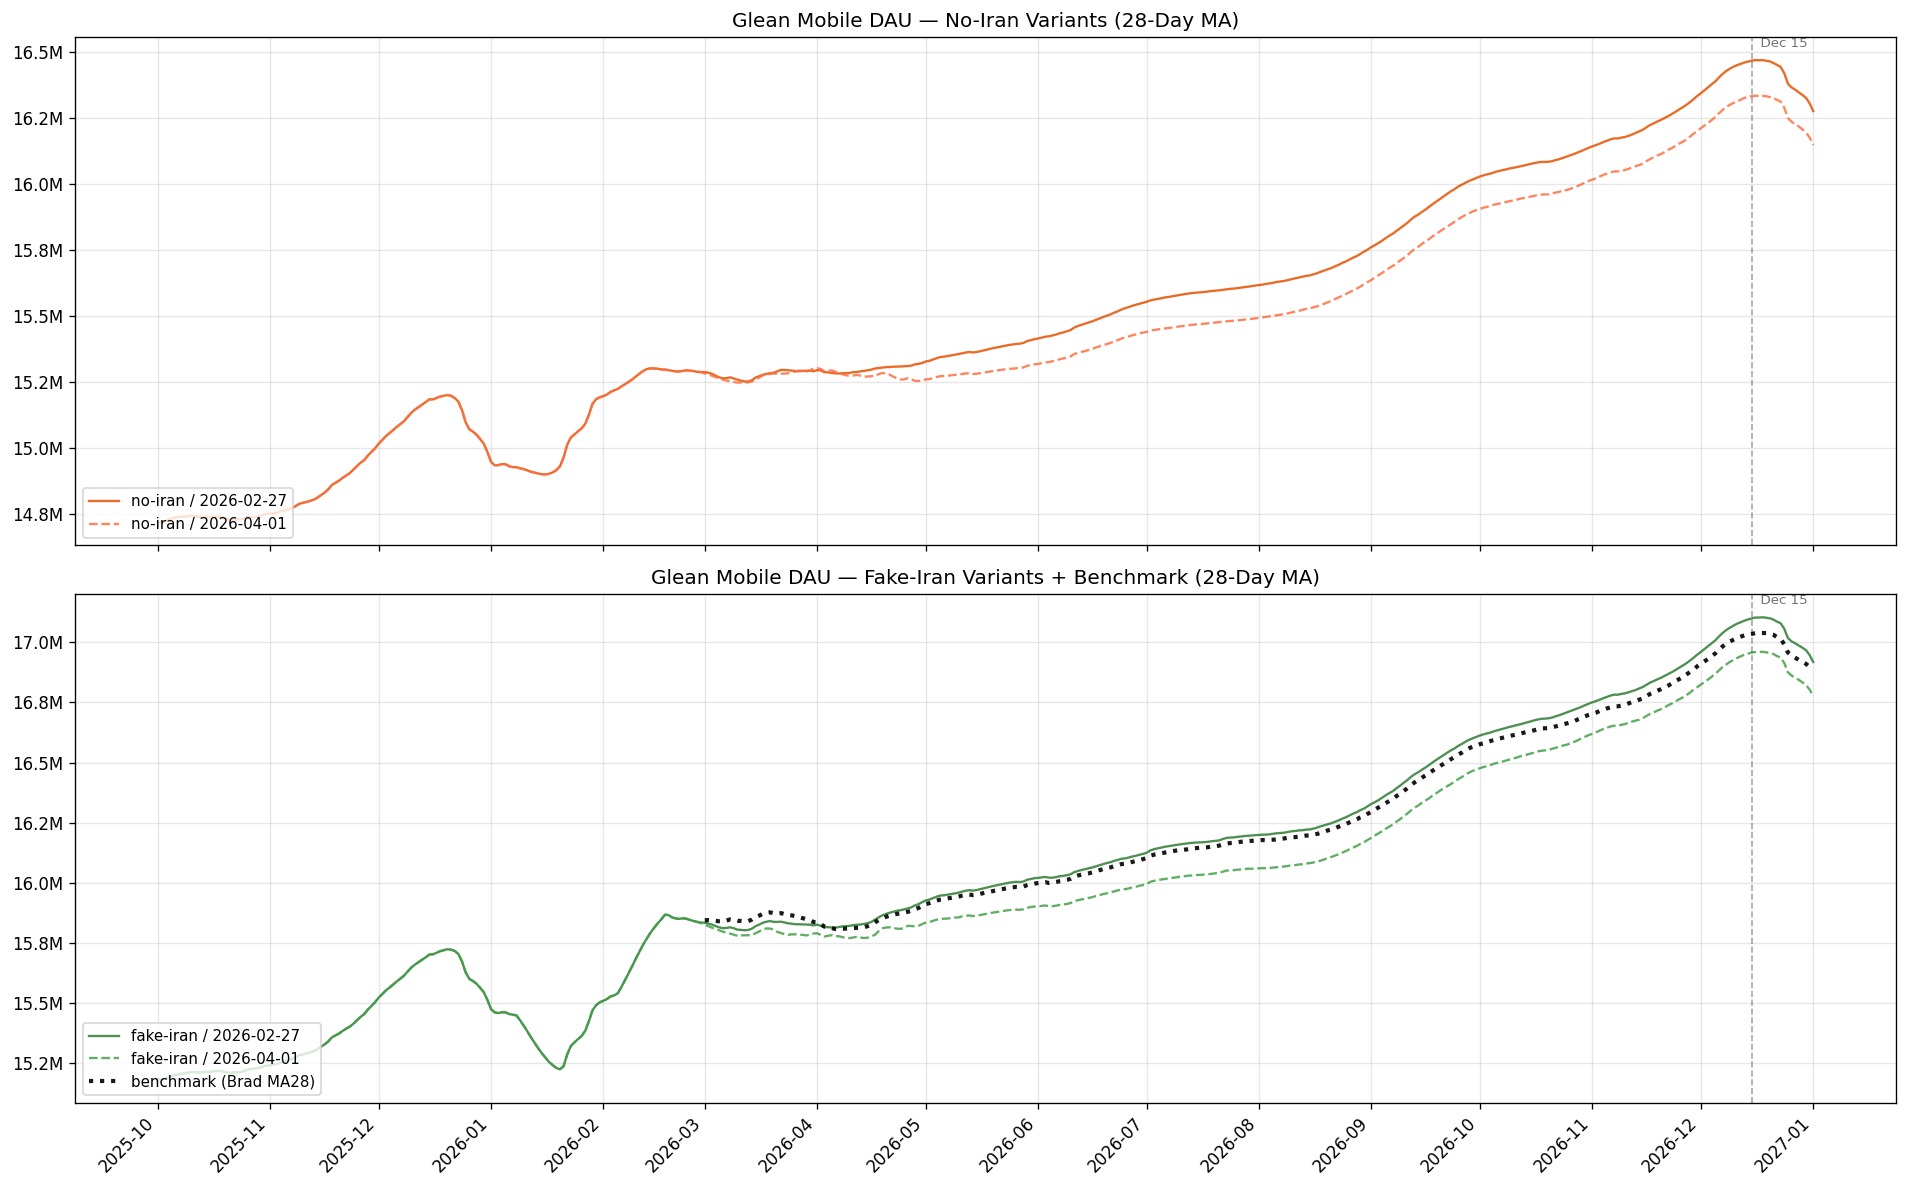

In [65]:
# [mobile-no-iran-vs-fake-iran]
plot_no_iran_vs_fake_iran(platform='mobile')


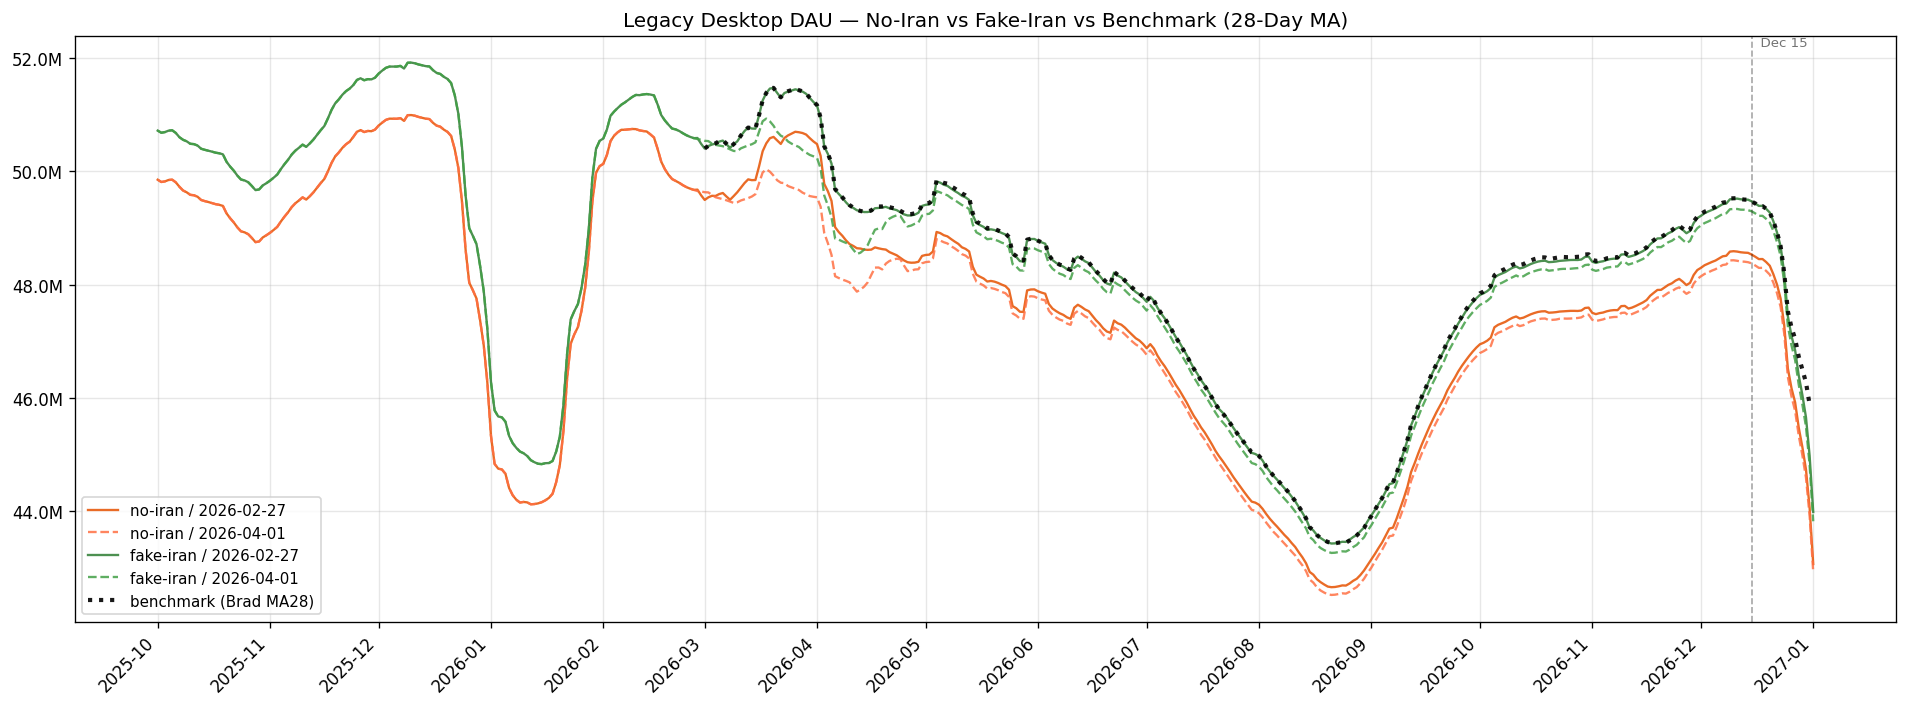

In [66]:
# [plot-combined]
def plot_combined(platform='desktop', start=PLOT_START, end=PLOT_END):
    """Single-pane MA28 plot with no-iran and fake-iran variants alongside benchmark.

    Parameters
    ----------
    platform : str
        'desktop' or 'mobile'
    start, end : pd.Timestamp
        Date window to display.
    """
    platform_data      = desktop_data      if platform == 'desktop' else mobile_data
    platform_benchmark = benchmark_desktop if platform == 'desktop' else benchmark_mobile
    platform_label     = 'Legacy Desktop DAU' if platform == 'desktop' else 'Glean Mobile DAU'

    variant_keys = [
        'no-iran/02-27', 'no-iran/04-01',
        'fake-iran/02-27', 'fake-iran/04-01',
    ]

    fig, ax = plt.subplots(figsize=(16, 6))

    for key in variant_keys:
        style   = DATASET_STYLES[key]
        df_ma   = add_ma28(platform_data[key])
        df_plot = trim(df_ma, start, end)
        ax.plot(df_plot['target_date'], df_plot['dau_ma28'],
                color=style['color'], linestyle=style['linestyle'],
                linewidth=style['linewidth'], alpha=0.85,
                label=style['label'])

    bstyle     = DATASET_STYLES['benchmark']
    bench_plot = trim(platform_benchmark, start, end)
    ax.plot(bench_plot['target_date'], bench_plot['dau_ma28'],
            color=bstyle['color'], linestyle=bstyle['linestyle'],
            linewidth=bstyle['linewidth'], alpha=0.9,
            label=bstyle['label'])

    ax.set_title(f'{platform_label} — No-Iran vs Fake-Iran vs Benchmark (28-Day MA)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
    ax.legend(loc='lower left', fontsize=9)
    mark_accounting_date(ax)
    apply_date_axis(ax)

    plt.tight_layout()
    plt.show()


plot_combined(platform='desktop')


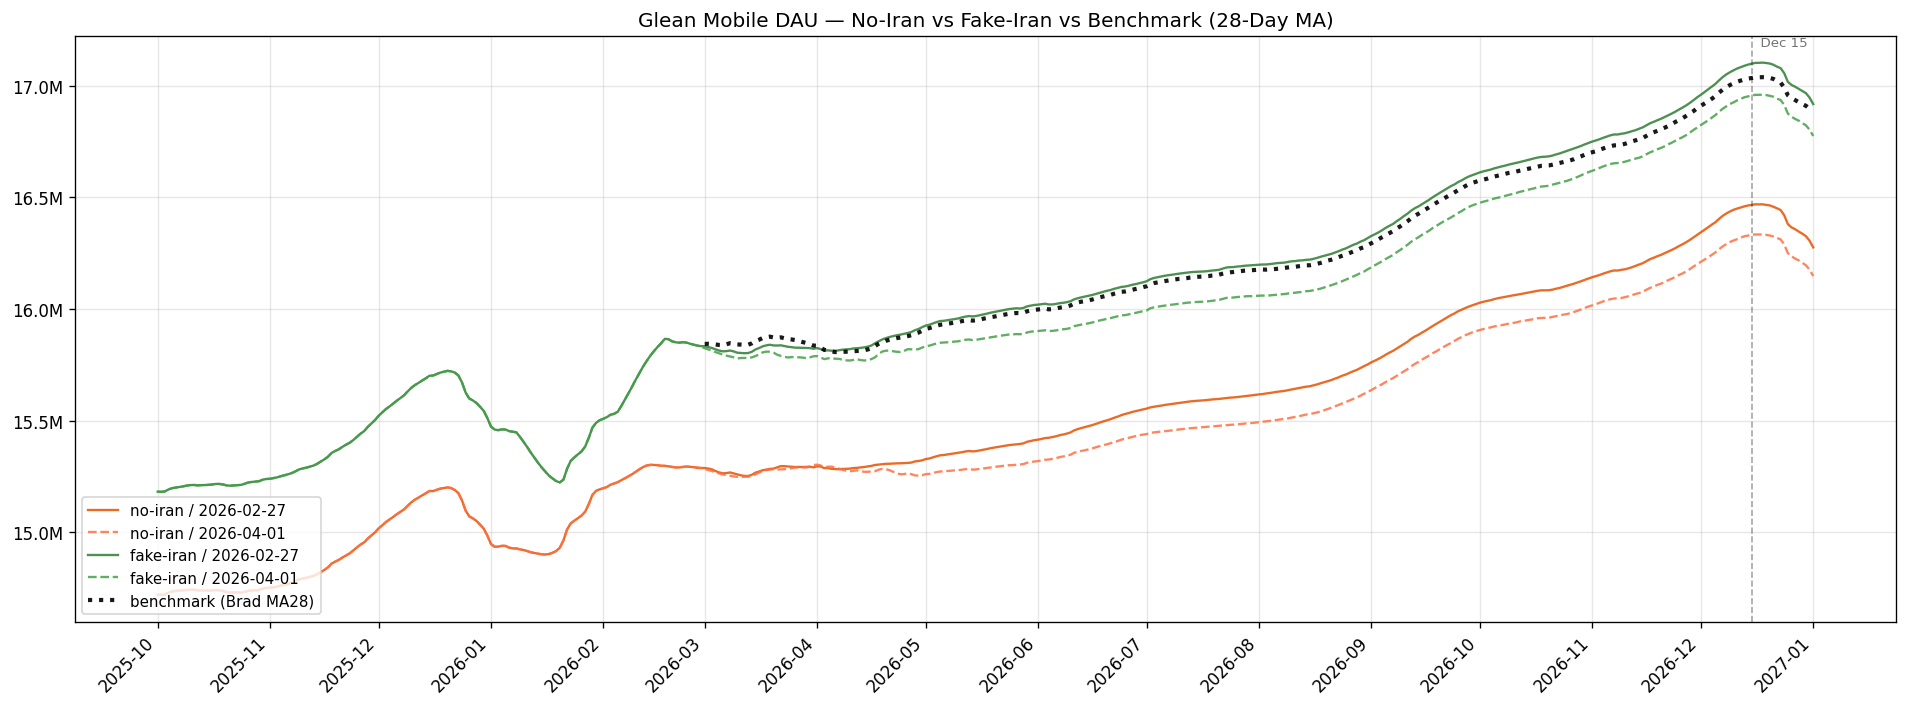

In [67]:
# [mobile-combined]
plot_combined(platform='mobile')


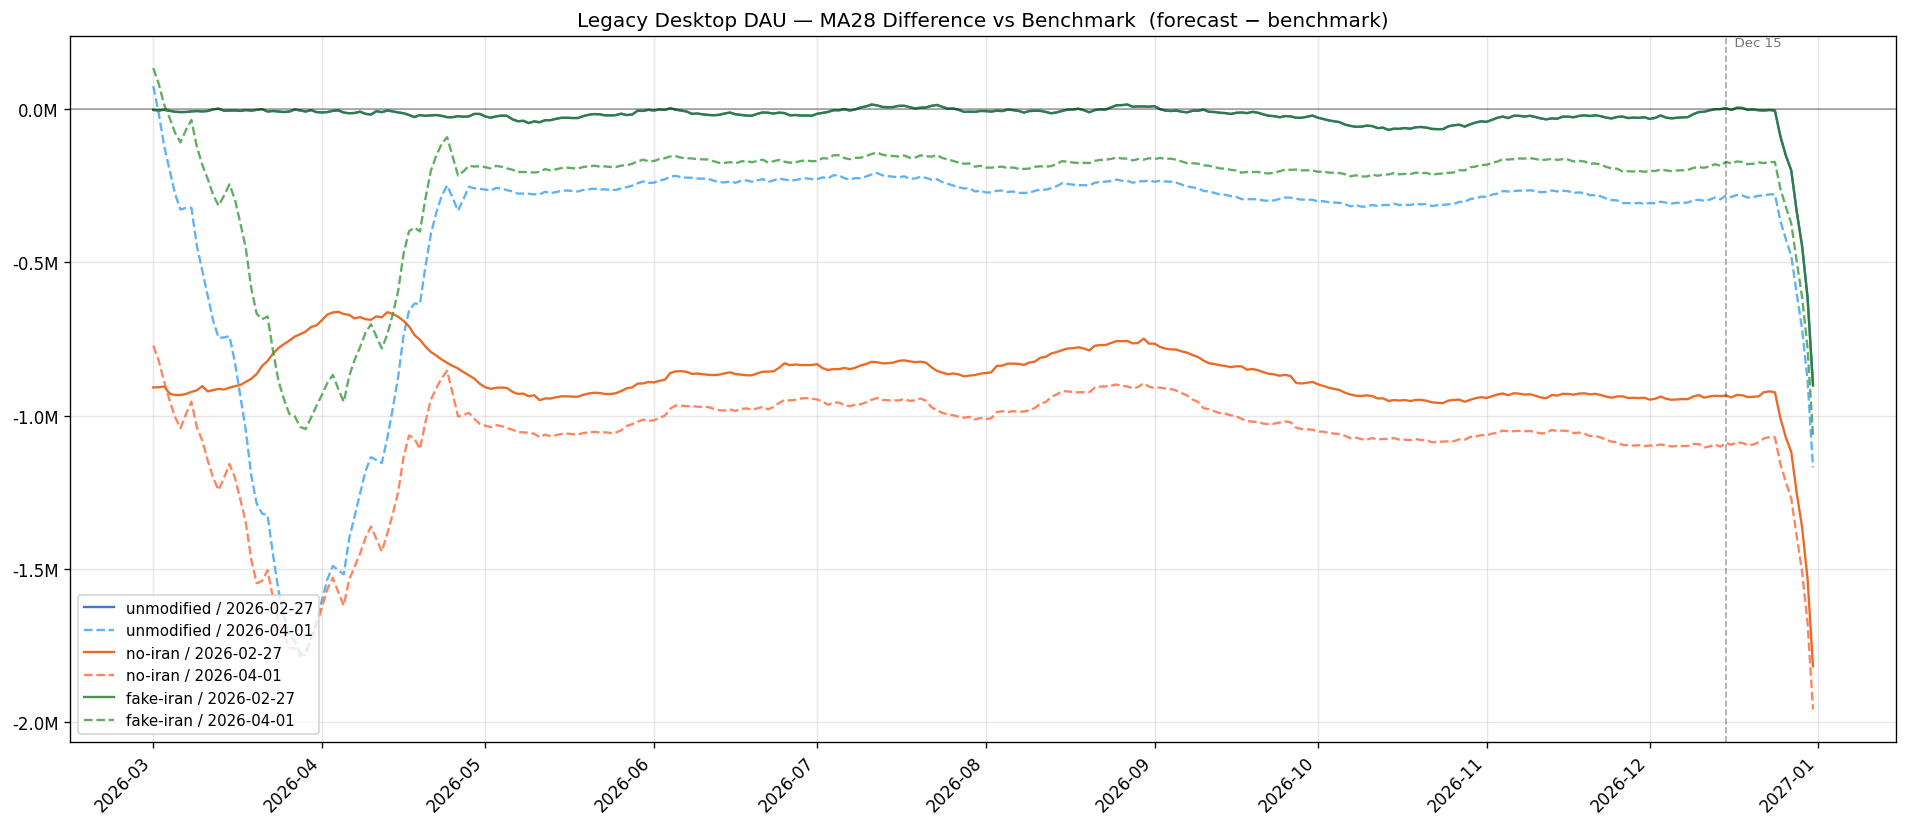

In [68]:
# [diff-plots]
def plot_diffs_vs_benchmark(keys=None, platform='desktop', start=BENCHMARK_START, end=PLOT_END):
    """Plot MA28 difference (forecast − benchmark) for selected variants on one axis.

    Restricted to the benchmark date window (2026-03-01 to 2026-12-31).
    Positive values mean the forecast is higher than the benchmark.

    Parameters
    ----------
    keys : list of str, optional
        Forecast keys to include. Defaults to all 9. Valid values:
            'april/02-27', 'april/04-01', 'april/04-05',
            'no-iran/02-27', 'no-iran/04-01', 'no-iran/04-05',
            'fake-iran/02-27', 'fake-iran/04-01', 'fake-iran/04-05'
    platform : str
        'desktop' or 'mobile'
    start, end : pd.Timestamp
        Date window to display.
    """
    if keys is None:
        keys = ALL_FORECAST_KEYS

    platform_data      = desktop_data      if platform == 'desktop' else mobile_data
    platform_benchmark = benchmark_desktop if platform == 'desktop' else benchmark_mobile
    platform_label     = 'Legacy Desktop DAU' if platform == 'desktop' else 'Glean Mobile DAU'

    fig, ax = plt.subplots(figsize=(16, 7))

    for key in keys:
        style  = DATASET_STYLES[key]
        df_ma  = add_ma28(platform_data[key])
        merged = df_ma.merge(
            platform_benchmark[['target_date', 'dau_ma28']],
            on='target_date',
            suffixes=('_forecast', '_bench'),
        )
        merged['diff'] = merged['dau_ma28_forecast'] - merged['dau_ma28_bench']
        df_plot = trim(merged, start, end)
        ax.plot(df_plot['target_date'], df_plot['diff'],
                color=style['color'], linestyle=style['linestyle'],
                linewidth=style['linewidth'], alpha=0.85,
                label=style['label'])

    ax.axhline(0, color='black', linestyle='-', alpha=0.35, linewidth=1)
    ax.set_title(f'{platform_label} — MA28 Difference vs Benchmark  (forecast − benchmark)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
    ax.legend(loc='lower left', fontsize=9)
    mark_accounting_date(ax)
    apply_date_axis(ax)

    plt.tight_layout()
    plt.show()


plot_diffs_vs_benchmark(platform='desktop')

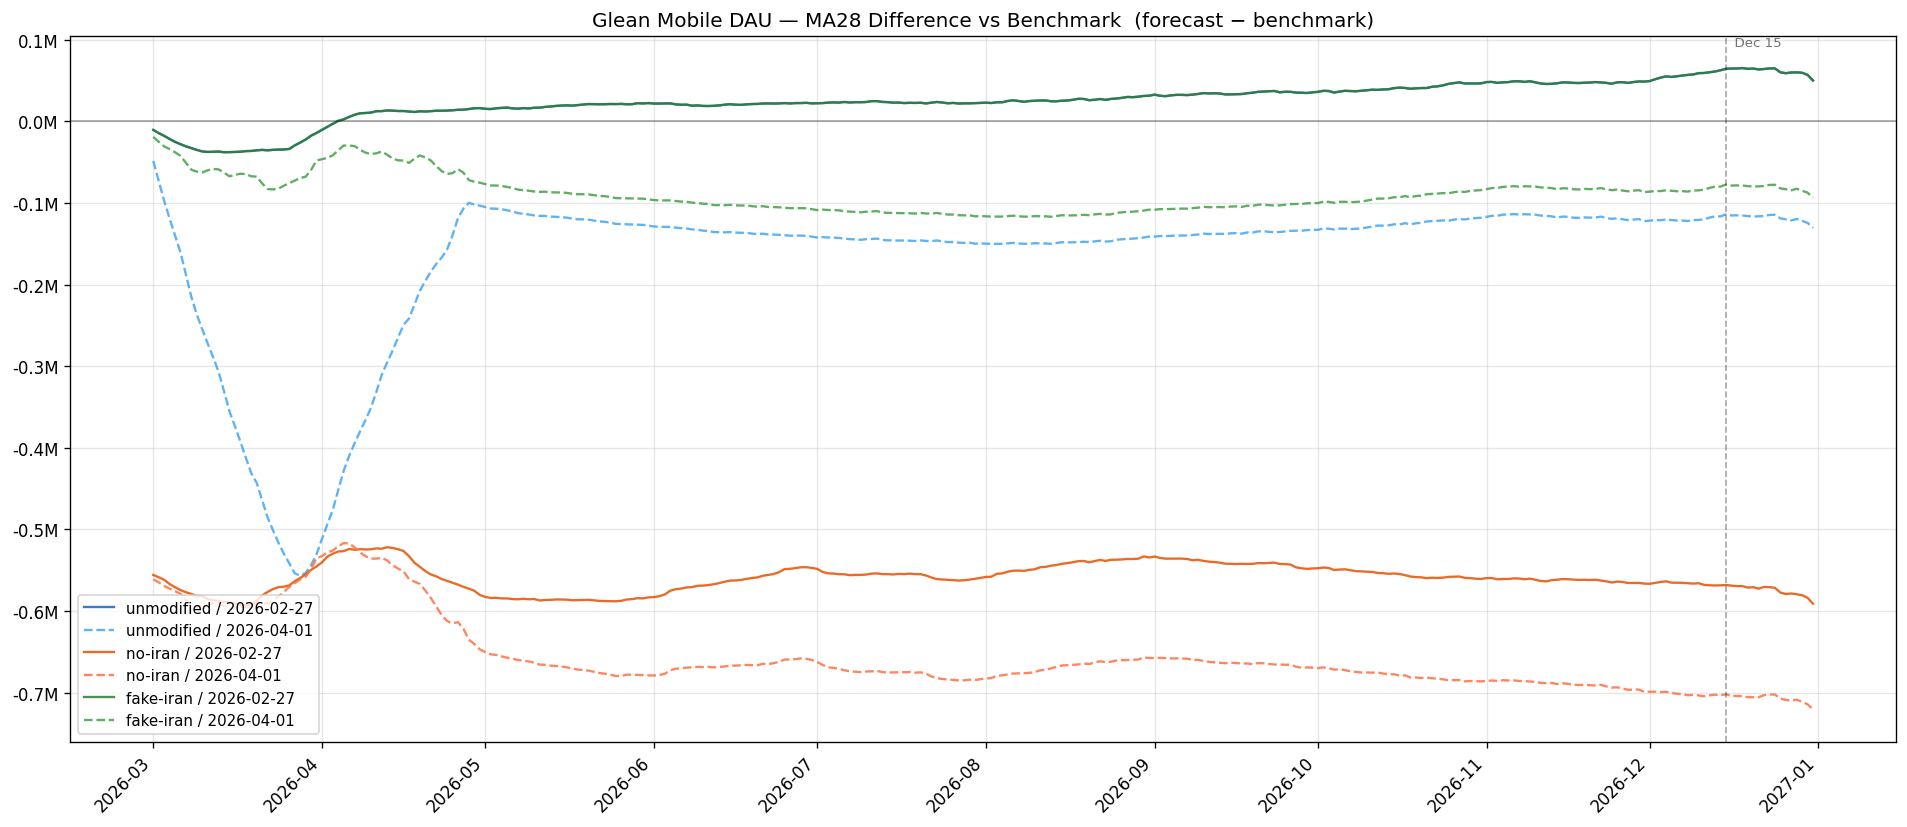

In [69]:
# [mobile-diffs]
plot_diffs_vs_benchmark(platform='mobile')

In [70]:
# [dec15-table]
# Compare MA28 values on the Dec 15 accounting date across all datasets + benchmark

def ma28_at_date(df, target_dt, value_col='dau_ma28'):
    """Return the MA28 value for a single date, or NaN if not present."""
    row = df.loc[df['target_date'] == target_dt, value_col]
    return row.iloc[0] if len(row) else np.nan


rows = []
for platform_label, platform_data, platform_benchmark in [
    ('Legacy Desktop', desktop_data, benchmark_desktop),
    ('Glean Mobile',   mobile_data,  benchmark_mobile),
]:
    bench_val = ma28_at_date(platform_benchmark, ACCOUNTING_DATE)

    for key in ALL_FORECAST_KEYS:
        df_ma        = add_ma28(platform_data[key])
        forecast_val = ma28_at_date(df_ma, ACCOUNTING_DATE)
        diff         = forecast_val - bench_val
        pct_diff     = diff / bench_val * 100
        rows.append({
            'Platform':       platform_label,
            'Dataset':        DATASET_STYLES[key]['label'],
            'Forecast MA28':  forecast_val,
            'Benchmark MA28': bench_val,
            'Diff (M)':       diff / 1e6,
            'Diff (%)':       pct_diff,
        })

dec15_table = pd.DataFrame(rows)

# Format for display
display_table = dec15_table.copy()
display_table['Forecast MA28']  = display_table['Forecast MA28'].apply(lambda x: f'{x/1e6:.3f}M')
display_table['Benchmark MA28'] = display_table['Benchmark MA28'].apply(lambda x: f'{x/1e6:.3f}M')
display_table['Diff (M)']       = display_table['Diff (M)'].apply(lambda x: f'{x:+.3f}M')
display_table['Diff (%)']       = display_table['Diff (%)'].apply(lambda x: f'{x:+.2f}%')

print(f'MA28 values on {ACCOUNTING_DATE.date()} (Dec 15 accounting date)')
print()
for platform_label in ['Legacy Desktop', 'Glean Mobile']:
    subset = display_table[display_table['Platform'] == platform_label].drop(columns='Platform')
    print(f'=== {platform_label} ===')
    print(subset.to_string(index=False))
    print()

MA28 values on 2026-12-15 (Dec 15 accounting date)

=== Legacy Desktop ===
                Dataset Forecast MA28 Benchmark MA28 Diff (M) Diff (%)
unmodified / 2026-02-27       49.467M        49.463M  +0.004M   +0.01%
unmodified / 2026-04-01       49.182M        49.463M  -0.281M   -0.57%
   no-iran / 2026-02-27       48.528M        49.463M  -0.935M   -1.89%
   no-iran / 2026-04-01       48.373M        49.463M  -1.090M   -2.20%
 fake-iran / 2026-02-27       49.467M        49.463M  +0.004M   +0.01%
 fake-iran / 2026-04-01       49.292M        49.463M  -0.171M   -0.35%

=== Glean Mobile ===
                Dataset Forecast MA28 Benchmark MA28 Diff (M) Diff (%)
unmodified / 2026-02-27       17.099M        17.035M  +0.064M   +0.38%
unmodified / 2026-04-01       16.921M        17.035M  -0.114M   -0.67%
   no-iran / 2026-02-27       16.467M        17.035M  -0.568M   -3.34%
   no-iran / 2026-04-01       16.333M        17.035M  -0.702M   -4.12%
 fake-iran / 2026-02-27       17.099M        17.035

In [71]:
# [dec15-table-vs-0227]
# Compare MA28 values on the Dec 15 accounting date: each variant vs its own 02-27 baseline

BASELINE_SUFFIX = '02-27'

rows = []
for platform_label, platform_data in [
    ('Legacy Desktop', desktop_data),
    ('Glean Mobile',   mobile_data),
]:
    for key in ALL_FORECAST_KEYS:
        spec, date_suffix = key.rsplit('/', 1)
        baseline_key = f'{spec}/{BASELINE_SUFFIX}'

        df_ma       = add_ma28(platform_data[key])
        df_baseline = add_ma28(platform_data[baseline_key])

        forecast_val = ma28_at_date(df_ma,       ACCOUNTING_DATE)
        baseline_val = ma28_at_date(df_baseline, ACCOUNTING_DATE)

        diff     = forecast_val - baseline_val
        pct_diff = diff / baseline_val * 100 if baseline_val else np.nan

        rows.append({
            'Platform':      platform_label,
            'Spec':          spec,
            'Date':          date_suffix,
            'Forecast MA28': forecast_val,
            'Baseline MA28': baseline_val,
            'Diff (M)':      diff / 1e6,
            'Diff (%)':      pct_diff,
        })

vs0227_table = pd.DataFrame(rows)

# Format for display
display_table = vs0227_table.copy()
display_table['Forecast MA28'] = display_table['Forecast MA28'].apply(lambda x: f'{x/1e6:.3f}M')
display_table['Baseline MA28'] = display_table['Baseline MA28'].apply(lambda x: f'{x/1e6:.3f}M')
display_table['Diff (M)']      = display_table['Diff (M)'].apply(lambda x: f'{x:+.3f}M')
display_table['Diff (%)']      = display_table['Diff (%)'].apply(lambda x: f'{x:+.2f}%' if not np.isnan(x) else '—')

print(f'MA28 values on {ACCOUNTING_DATE.date()} — each variant vs its own 02-27 baseline')
print()
for platform_label in ['Legacy Desktop', 'Glean Mobile']:
    subset = display_table[display_table['Platform'] == platform_label].drop(columns='Platform')
    print(f'=== {platform_label} ===')
    print(subset.to_string(index=False))
    print()


MA28 values on 2026-12-15 — each variant vs its own 02-27 baseline

=== Legacy Desktop ===
     Spec  Date Forecast MA28 Baseline MA28 Diff (M) Diff (%)
    april 02-27       49.467M       49.467M  +0.000M   +0.00%
    april 04-01       49.182M       49.467M  -0.285M   -0.58%
  no-iran 02-27       48.528M       48.528M  +0.000M   +0.00%
  no-iran 04-01       48.373M       48.528M  -0.155M   -0.32%
fake-iran 02-27       49.467M       49.467M  +0.000M   +0.00%
fake-iran 04-01       49.292M       49.467M  -0.175M   -0.35%

=== Glean Mobile ===
     Spec  Date Forecast MA28 Baseline MA28 Diff (M) Diff (%)
    april 02-27       17.099M       17.099M  +0.000M   +0.00%
    april 04-01       16.921M       17.099M  -0.178M   -1.04%
  no-iran 02-27       16.467M       16.467M  +0.000M   +0.00%
  no-iran 04-01       16.333M       16.467M  -0.134M   -0.81%
fake-iran 02-27       17.099M       17.099M  +0.000M   +0.00%
fake-iran 04-01       16.957M       17.099M  -0.142M   -0.83%

